# **SpaceX Falcon 9 First Stage Landing Prediction**

## Advanced Feature Engineering & Data Preprocessing

---

### Executive Summary

This notebook enhances the original data preprocessing pipeline with advanced feature engineering techniques to improve model performance. We implement:

- **Temporal Features**: Extract year, month, quarter, day of week from launch dates
- **Booster Experience Features**: Calculate cumulative flights, days since first flight
- **Rolling Success Rates**: Site-specific and orbit-specific success rates
- **Payload Categories**: Bin payload mass into meaningful categories
- **Geographic Features**: Distance to equator, coastal proximity
- **Interaction Features**: Payload-orbit interactions
- **Advanced Imputation**: KNN imputation instead of simple mean
- **Outlier Detection**: IQR and Isolation Forest methods
- **Feature Scaling Comparison**: StandardScaler vs MinMaxScaler vs RobustScaler

**Note**: We maintain the November 2020 data cutoff for ML training due to post-2020 SpaceX achieving 97%+ success rates, which would create severe class imbalance.

---

### Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load and Explore Data](#2-load-and-explore-data)
3. [Temporal Feature Engineering](#3-temporal-feature-engineering)
4. [Booster Experience Features](#4-booster-experience-features)
5. [Rolling Success Rate Features](#5-rolling-success-rate-features)
6. [Payload Categories](#6-payload-categories)
7. [Geographic Features](#7-geographic-features)
8. [Interaction Features](#8-interaction-features)
9. [Advanced Missing Value Handling](#9-advanced-missing-value-handling)
10. [Outlier Detection](#10-outlier-detection)
11. [Feature Scaling Comparison](#11-feature-scaling-comparison)
12. [Final Feature Set Export](#12-final-feature-set-export)

---

## 1. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import IsolationForest

# Geographic calculations
from math import sin, cos, sqrt, atan2, radians

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5


---

## 2. Load and Explore Data

In [2]:
# Load the dataset from previous data wrangling
df = pd.read_csv('Datasets/dataset_part_2.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nDataset Columns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nSuccess Rate: {df['Class'].mean()*100:.2f}%")

Dataset Shape: (90, 18)

Dataset Columns (18):
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']

Class Distribution:
Class
1    60
0    30
Name: count, dtype: int64

Success Rate: 66.67%


In [3]:
# Display first few rows
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nMissing Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Data Types:
FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
Class               int64
dtype: object


Missing Values:
FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

Missing Percentage:
FlightNumber       0.00
Date               0.00
BoosterVersion     0.00
Payl

---

## 3. Temporal Feature Engineering

Extract meaningful time-based features from launch dates to capture temporal patterns in landing success.

In [5]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract temporal features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayOfYear'] = df['Date'].dt.dayofyear
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Calculate days since first SpaceX Falcon 9 launch (June 4, 2010)
first_launch_date = pd.to_datetime('2010-06-04')
df['DaysSinceFirstLaunch'] = (df['Date'] - first_launch_date).dt.days

# Is weekend launch?
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

print("Temporal Features Created:")
print(df[['Date', 'Year', 'Month', 'Quarter', 'DayOfWeek', 'DaysSinceFirstLaunch', 'IsWeekend']].head(10))

Temporal Features Created:
        Date  Year  Month  Quarter  DayOfWeek  DaysSinceFirstLaunch  IsWeekend
0 2010-06-04  2010      6        2          4                     0          0
1 2012-05-22  2012      5        2          1                   718          0
2 2013-03-01  2013      3        1          4                  1001          0
3 2013-09-29  2013      9        3          6                  1213          1
4 2013-12-03  2013     12        4          1                  1278          0
5 2014-01-06  2014      1        1          0                  1312          0
6 2014-04-18  2014      4        2          4                  1414          0
7 2014-07-14  2014      7        3          0                  1501          0
8 2014-08-05  2014      8        3          1                  1523          0
9 2014-09-07  2014      9        3          6                  1556          1


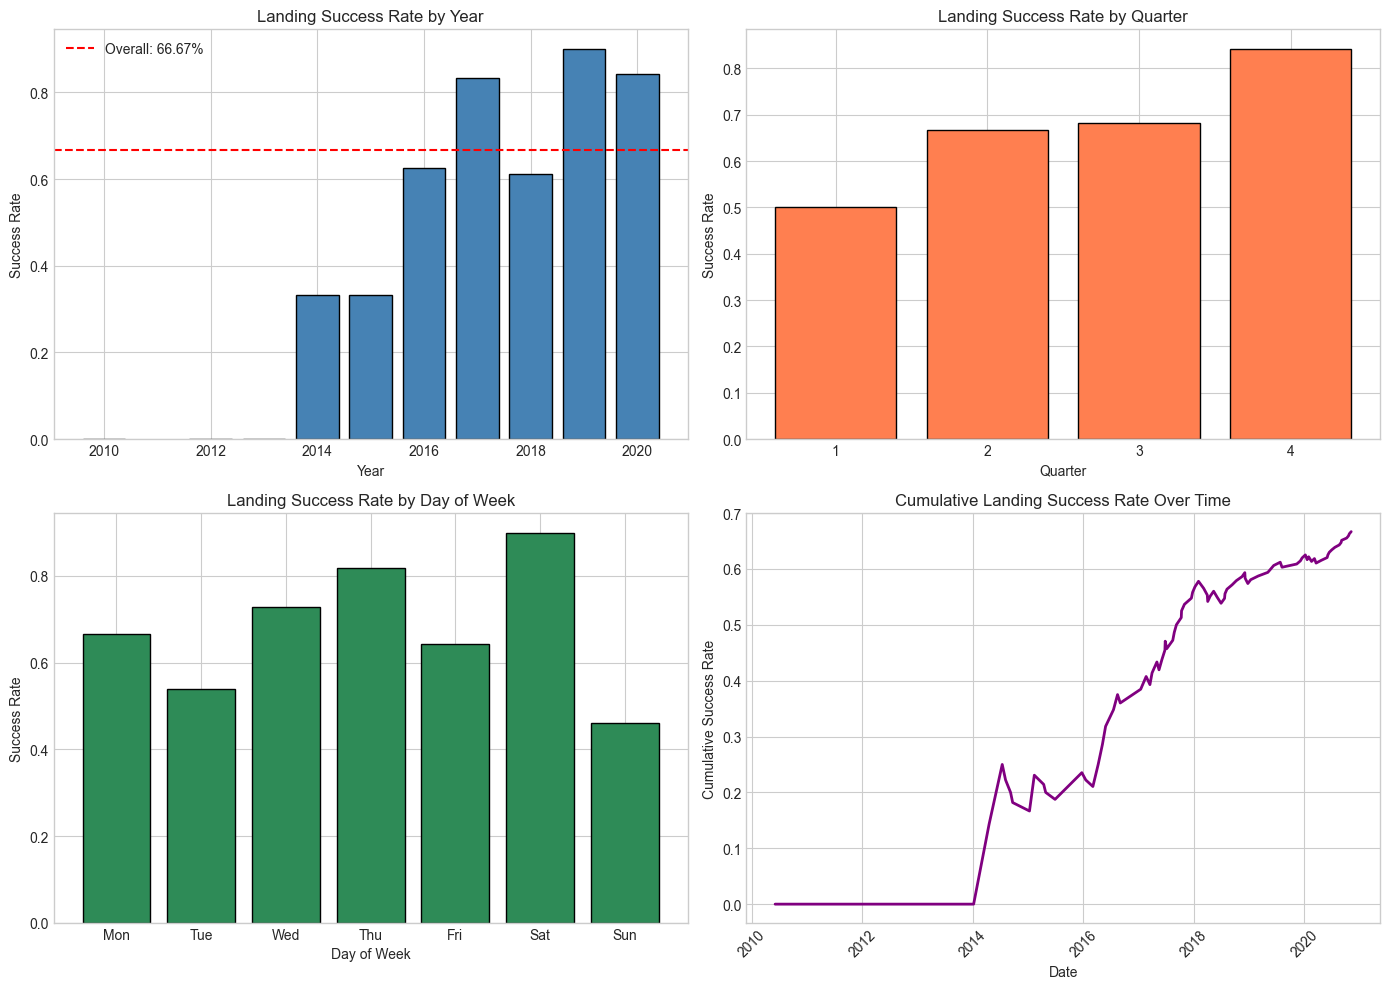

In [6]:
# Visualize success rate by year
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Success rate by Year
yearly_success = df.groupby('Year')['Class'].mean()
axes[0, 0].bar(yearly_success.index, yearly_success.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Success Rate')
axes[0, 0].set_title('Landing Success Rate by Year')
axes[0, 0].axhline(y=df['Class'].mean(), color='red', linestyle='--', label=f'Overall: {df["Class"].mean():.2%}')
axes[0, 0].legend()

# Success rate by Quarter
quarterly_success = df.groupby('Quarter')['Class'].mean()
axes[0, 1].bar(quarterly_success.index, quarterly_success.values, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Quarter')
axes[0, 1].set_ylabel('Success Rate')
axes[0, 1].set_title('Landing Success Rate by Quarter')
axes[0, 1].set_xticks([1, 2, 3, 4])

# Success rate by Day of Week
dow_success = df.groupby('DayOfWeek')['Class'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(7), dow_success.values, color='seagreen', edgecolor='black')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(days)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Success Rate')
axes[1, 0].set_title('Landing Success Rate by Day of Week')

# Cumulative success over time
df_sorted = df.sort_values('Date')
df_sorted['CumulativeSuccess'] = df_sorted['Class'].expanding().mean()
axes[1, 1].plot(df_sorted['Date'], df_sorted['CumulativeSuccess'], color='purple', linewidth=2)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Cumulative Success Rate')
axes[1, 1].set_title('Cumulative Landing Success Rate Over Time')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Datasets/temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 4. Booster Experience Features

Create features that capture the experience and history of each booster to improve predictions.

In [7]:
# Sort by date to ensure proper ordering
df = df.sort_values('Date').reset_index(drop=True)

# Calculate cumulative flight number (experience proxy)
df['CumulativeFlightNumber'] = range(1, len(df) + 1)

# Calculate days since booster's first flight
booster_first_flight = df.groupby('Serial')['Date'].transform('min')
df['DaysSinceBoosterFirstFlight'] = (df['Date'] - booster_first_flight).dt.days

# Calculate booster age in flights (how many times this specific booster has flown before)
df['BoosterFlightSequence'] = df.groupby('Serial').cumcount() + 1

# Calculate average success rate of this booster (prior to current flight)
def calculate_booster_prior_success(group):
    prior_success = group['Class'].expanding().mean().shift(1)
    return prior_success.fillna(0.5)  # First flight gets 0.5 (unknown)

df['BoosterPriorSuccessRate'] = df.groupby('Serial', group_keys=False).apply(
    lambda x: calculate_booster_prior_success(x)
)

# Calculate total prior flights for this booster version (Block)
def calculate_block_experience(group):
    return group.expanding().count().shift(1).fillna(0)

df['BlockCumulativeFlights'] = df.groupby('Block', group_keys=False)['FlightNumber'].apply(
    lambda x: x.expanding().count().shift(1).fillna(0)
)

print("Booster Experience Features:")
print(df[['Serial', 'Date', 'Flights', 'ReusedCount', 'BoosterFlightSequence', 
          'DaysSinceBoosterFirstFlight', 'BoosterPriorSuccessRate']].head(15))

Booster Experience Features:
   Serial       Date  Flights  ReusedCount  BoosterFlightSequence  \
0   B0003 2010-06-04        1            0                      1   
1   B0005 2012-05-22        1            0                      1   
2   B0007 2013-03-01        1            0                      1   
3   B1003 2013-09-29        1            0                      1   
4   B1004 2013-12-03        1            0                      1   
5   B1005 2014-01-06        1            0                      1   
6   B1006 2014-04-18        1            0                      1   
7   B1007 2014-07-14        1            0                      1   
8   B1008 2014-08-05        1            0                      1   
9   B1011 2014-09-07        1            0                      1   
10  B1010 2014-09-21        1            0                      1   
11  B1012 2015-01-10        1            0                      1   
12  B1013 2015-02-11        1            0                      1   
13  B

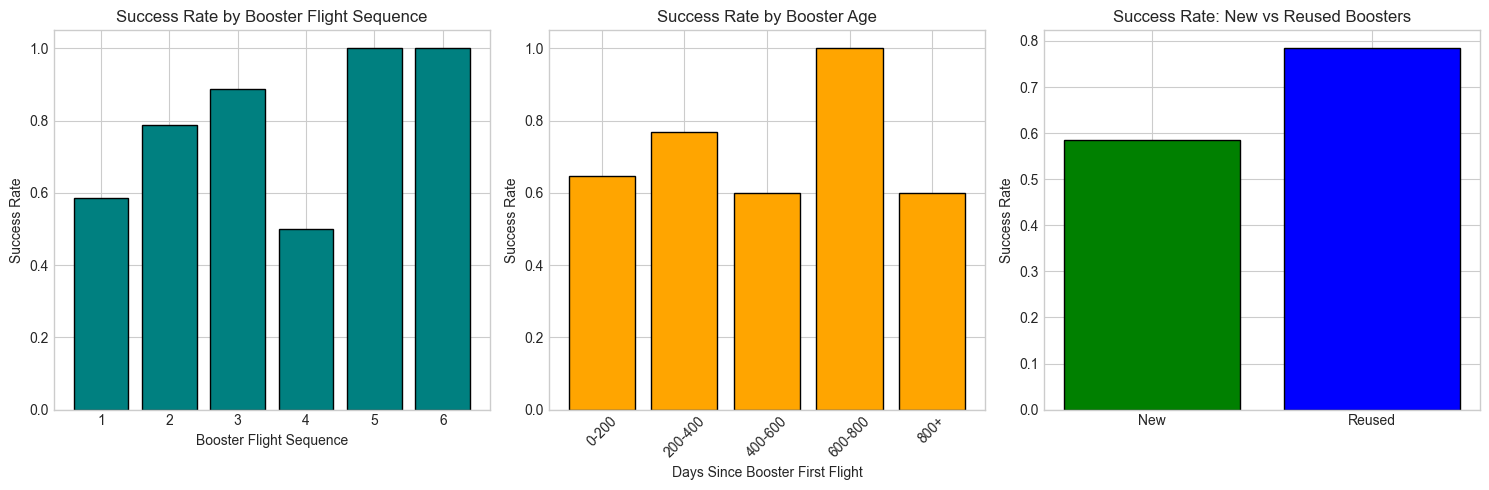

In [8]:
# Visualize booster experience impact
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Success rate by booster flight sequence
flight_seq_success = df.groupby('BoosterFlightSequence')['Class'].agg(['mean', 'count'])
axes[0].bar(flight_seq_success.index, flight_seq_success['mean'], color='teal', edgecolor='black')
axes[0].set_xlabel('Booster Flight Sequence')
axes[0].set_ylabel('Success Rate')
axes[0].set_title('Success Rate by Booster Flight Sequence')

# Success rate by days since booster first flight
df['DaysBoosterBinned'] = pd.cut(df['DaysSinceBoosterFirstFlight'], bins=5, labels=['0-200', '200-400', '400-600', '600-800', '800+'])
binned_success = df.groupby('DaysBoosterBinned', observed=True)['Class'].mean()
axes[1].bar(range(len(binned_success)), binned_success.values, color='orange', edgecolor='black')
axes[1].set_xticks(range(len(binned_success)))
axes[1].set_xticklabels(binned_success.index, rotation=45)
axes[1].set_xlabel('Days Since Booster First Flight')
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Success Rate by Booster Age')

# Reused vs New boosters success rate
reuse_success = df.groupby('Reused')['Class'].mean()
axes[2].bar(['New', 'Reused'], reuse_success.values, color=['green', 'blue'], edgecolor='black')
axes[2].set_ylabel('Success Rate')
axes[2].set_title('Success Rate: New vs Reused Boosters')

plt.tight_layout()
plt.savefig('Datasets/booster_experience_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 5. Rolling Success Rate Features

Calculate rolling success rates by launch site and orbit type to capture historical performance patterns.

In [9]:
# Calculate rolling success rate by launch site (prior to current flight)
def calculate_rolling_success(group, window=5):
    """Calculate rolling success rate with a lookback window"""
    rolling = group['Class'].shift(1).rolling(window=window, min_periods=1).mean()
    return rolling.fillna(0.5)  # Unknown gets 0.5

# Site-based rolling success rate
df['SiteRollingSuccess_5'] = df.groupby('LaunchSite', group_keys=False).apply(
    lambda x: calculate_rolling_success(x, window=5)
)

# Overall rolling success rate
df['OverallRollingSuccess_5'] = df['Class'].shift(1).rolling(window=5, min_periods=1).mean().fillna(0.5)
df['OverallRollingSuccess_10'] = df['Class'].shift(1).rolling(window=10, min_periods=1).mean().fillna(0.5)

# Orbit-based rolling success rate
df['OrbitRollingSuccess_5'] = df.groupby('Orbit', group_keys=False).apply(
    lambda x: calculate_rolling_success(x, window=5)
)

# Site cumulative success rate (all prior flights at this site)
df['SiteCumulativeSuccess'] = df.groupby('LaunchSite', group_keys=False).apply(
    lambda x: x['Class'].expanding().mean().shift(1).fillna(0.5)
)

# Orbit cumulative success rate
df['OrbitCumulativeSuccess'] = df.groupby('Orbit', group_keys=False).apply(
    lambda x: x['Class'].expanding().mean().shift(1).fillna(0.5)
)

print("Rolling Success Rate Features:")
print(df[['LaunchSite', 'Orbit', 'SiteRollingSuccess_5', 'OrbitRollingSuccess_5', 
          'OverallRollingSuccess_5', 'SiteCumulativeSuccess']].head(15))

Rolling Success Rate Features:
      LaunchSite  Orbit  SiteRollingSuccess_5  OrbitRollingSuccess_5  \
0   CCSFS SLC 40    LEO                   0.5               0.500000   
1   CCSFS SLC 40    LEO                   0.0               0.000000   
2   CCSFS SLC 40    ISS                   0.0               0.500000   
3    VAFB SLC 4E     PO                   0.5               0.500000   
4   CCSFS SLC 40    GTO                   0.0               0.500000   
5   CCSFS SLC 40    GTO                   0.0               0.000000   
6   CCSFS SLC 40    ISS                   0.0               0.000000   
7   CCSFS SLC 40    LEO                   0.2               0.000000   
8   CCSFS SLC 40    GTO                   0.4               0.000000   
9   CCSFS SLC 40    GTO                   0.4               0.000000   
10  CCSFS SLC 40    ISS                   0.4               0.500000   
11  CCSFS SLC 40    ISS                   0.4               0.333333   
12  CCSFS SLC 40  ES-L1          

---

## 6. Payload Categories

Bin payload mass into meaningful categories based on Falcon 9 payload capacity characteristics.

In [10]:
# Define payload mass categories based on Falcon 9 capabilities
# Light: < 3000 kg
# Medium: 3000-7000 kg  
# Heavy: 7000-12000 kg
# Super Heavy: > 12000 kg

def categorize_payload(mass):
    if mass < 3000:
        return 'Light'
    elif mass < 7000:
        return 'Medium'
    elif mass < 12000:
        return 'Heavy'
    else:
        return 'SuperHeavy'

df['PayloadCategory'] = df['PayloadMass'].apply(categorize_payload)

# Create numeric encoding for payload category
payload_cat_map = {'Light': 1, 'Medium': 2, 'Heavy': 3, 'SuperHeavy': 4}
df['PayloadCategoryNumeric'] = df['PayloadCategory'].map(payload_cat_map)

# Calculate payload mass relative to category average
category_means = df.groupby('PayloadCategory')['PayloadMass'].transform('mean')
df['PayloadMassRelative'] = df['PayloadMass'] / category_means

# Log transform of payload mass (useful for skewed distributions)
df['PayloadMassLog'] = np.log1p(df['PayloadMass'])

print("Payload Category Distribution:")
print(df['PayloadCategory'].value_counts())
print("\nSuccess Rate by Payload Category:")
print(df.groupby('PayloadCategory')['Class'].mean().sort_values(ascending=False))

Payload Category Distribution:
PayloadCategory
Medium        37
Light         28
SuperHeavy    15
Heavy         10
Name: count, dtype: int64

Success Rate by Payload Category:
PayloadCategory
Heavy         0.900000
SuperHeavy    0.866667
Light         0.607143
Medium        0.567568
Name: Class, dtype: float64


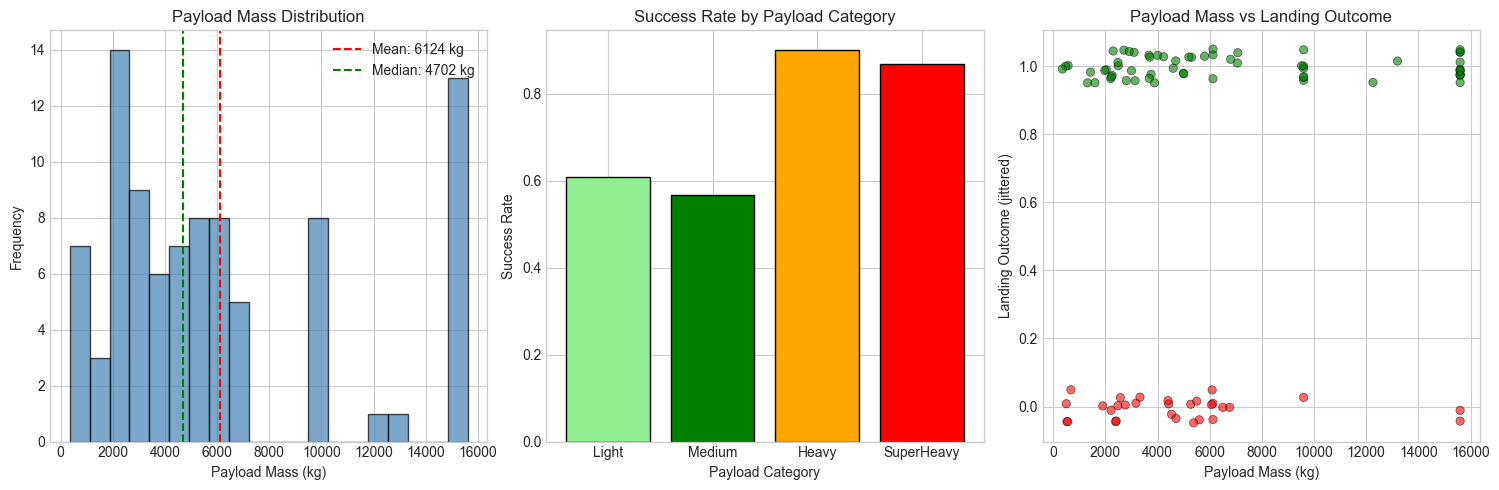

In [11]:
# Visualize payload analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Payload mass distribution
axes[0].hist(df['PayloadMass'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['PayloadMass'].mean(), color='red', linestyle='--', label=f'Mean: {df["PayloadMass"].mean():.0f} kg')
axes[0].axvline(df['PayloadMass'].median(), color='green', linestyle='--', label=f'Median: {df["PayloadMass"].median():.0f} kg')
axes[0].set_xlabel('Payload Mass (kg)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Payload Mass Distribution')
axes[0].legend()

# Success rate by payload category
cat_order = ['Light', 'Medium', 'Heavy', 'SuperHeavy']
cat_success = df.groupby('PayloadCategory')['Class'].mean().reindex(cat_order)
colors = ['lightgreen', 'green', 'orange', 'red']
axes[1].bar(cat_order, cat_success.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Payload Category')
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Success Rate by Payload Category')

# Payload mass vs success (scatter with color)
colors = df['Class'].map({0: 'red', 1: 'green'})
axes[2].scatter(df['PayloadMass'], df['Class'] + np.random.uniform(-0.05, 0.05, len(df)), 
                c=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Payload Mass (kg)')
axes[2].set_ylabel('Landing Outcome (jittered)')
axes[2].set_title('Payload Mass vs Landing Outcome')

plt.tight_layout()
plt.savefig('Datasets/payload_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 7. Geographic Features

Calculate geographic features including distance to equator and coastal proximity.

In [12]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    R = 6371  # Radius of Earth in kilometers
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

# Distance to equator (latitude = 0)
df['DistanceToEquator'] = df['Latitude'].apply(
    lambda lat: haversine_distance(lat, 0, 0, 0)
)

# Approximate coastal distances (based on known geography)
# CCSFS and KSC are on the Florida coast (~0 km to coast)
# VAFB is on California coast (~0 km to coast)
coastal_distances = {
    'CCSFS SLC 40': 0.5,   # Very close to coast
    'KSC LC 39A': 3.88,    # From Folium analysis
    'VAFB SLC 4E': 0.8     # On California coast
}
df['DistanceToCoast'] = df['LaunchSite'].map(coastal_distances)

# Absolute latitude (distance from equator in degrees)
df['AbsoluteLatitude'] = df['Latitude'].abs()

# Is east coast launch site?
df['IsEastCoast'] = (df['Longitude'] > -100).astype(int)

print("Geographic Features:")
print(df[['LaunchSite', 'Latitude', 'Longitude', 'DistanceToEquator', 'DistanceToCoast', 'IsEastCoast']].drop_duplicates())

Geographic Features:
      LaunchSite   Latitude   Longitude  DistanceToEquator  DistanceToCoast  \
0   CCSFS SLC 40  28.561857  -80.577366        3175.933605             0.50   
3    VAFB SLC 4E  34.632093 -120.610829        3850.913041             0.80   
26    KSC LC 39A  28.608058  -80.603956        3181.070966             3.88   

    IsEastCoast  
0             1  
3             0  
26            1  


---

## 8. Interaction Features

Create interaction features between key variables that might have synergistic effects.

In [13]:
# Payload-Orbit Interaction
# GTO orbits typically require more fuel, leaving less for landing
orbit_difficulty = {
    'LEO': 1, 'ISS': 1, 'VLEO': 1,  # Low difficulty
    'PO': 2, 'SSO': 2,               # Medium difficulty
    'GTO': 3, 'MEO': 3,              # High difficulty
    'GEO': 4, 'HEO': 4, 'ES-L1': 4, 'SO': 4  # Very high difficulty
}
df['OrbitDifficulty'] = df['Orbit'].map(orbit_difficulty)

# Payload-Orbit interaction
df['PayloadOrbitInteraction'] = df['PayloadMass'] * df['OrbitDifficulty']

# Payload per flight (if reused)
df['PayloadPerFlight'] = df['PayloadMass'] / df['Flights']

# Experience-Reuse interaction
df['ExperienceReuseInteraction'] = df['CumulativeFlightNumber'] * df['Reused'].astype(int)

# GridFins-Legs combination (both needed for landing)
df['LandingHardwareScore'] = df['GridFins'].astype(int) + df['Legs'].astype(int)

# Block-Reuse interaction
df['BlockReuseInteraction'] = df['Block'] * (df['Reused'].astype(int) + 1)

print("Interaction Features Created:")
print(df[['PayloadMass', 'Orbit', 'OrbitDifficulty', 'PayloadOrbitInteraction', 
          'LandingHardwareScore', 'BlockReuseInteraction']].head(10))

Interaction Features Created:
   PayloadMass Orbit  OrbitDifficulty  PayloadOrbitInteraction  \
0  6123.547647   LEO                1              6123.547647   
1   525.000000   LEO                1               525.000000   
2   677.000000   ISS                1               677.000000   
3   500.000000    PO                2              1000.000000   
4  3170.000000   GTO                3              9510.000000   
5  3325.000000   GTO                3              9975.000000   
6  2296.000000   ISS                1              2296.000000   
7  1316.000000   LEO                1              1316.000000   
8  4535.000000   GTO                3             13605.000000   
9  4428.000000   GTO                3             13284.000000   

   LandingHardwareScore  BlockReuseInteraction  
0                     0                    1.0  
1                     0                    1.0  
2                     0                    1.0  
3                     0                    1.0 

---

## 9. Advanced Missing Value Handling

Implement KNN imputation for missing values instead of simple mean imputation.

In [14]:
# Check for missing values in numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Missing values in numeric columns:")
print(df[numeric_cols].isnull().sum()[df[numeric_cols].isnull().sum() > 0])

Missing values in numeric columns:
Series([], dtype: int64)


In [15]:
# For LandingPad - this is expected to be missing when no landing was attempted
# Create a binary feature indicating if landing pad was used
df['LandingPadUsed'] = df['LandingPad'].notna().astype(int)

# Handle any remaining numeric missing values with KNN imputation
numeric_features_to_impute = ['PayloadMass', 'Block', 'OrbitDifficulty']
existing_features = [f for f in numeric_features_to_impute if f in df.columns and df[f].isnull().any()]

if existing_features:
    imputer = KNNImputer(n_neighbors=5)
    df[existing_features] = imputer.fit_transform(df[existing_features])
    print(f"KNN imputation applied to: {existing_features}")
else:
    print("No numeric columns require imputation.")

# Fill any remaining NaN in derived features
df = df.fillna({
    'DistanceToCoast': df['DistanceToCoast'].median(),
    'OrbitDifficulty': 2,  # Default to medium
    'Block': df['Block'].mode()[0] if not df['Block'].mode().empty else 1
})

No numeric columns require imputation.


---

## 10. Outlier Detection

Detect and flag outliers using IQR and Isolation Forest methods.

In [16]:
def detect_outliers_iqr(data, column, threshold=1.5):
    """
    Detect outliers using IQR method
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    return outliers, lower_bound, upper_bound

# Detect outliers in PayloadMass
payload_outliers, pl_lower, pl_upper = detect_outliers_iqr(df, 'PayloadMass')
df['PayloadMassOutlier'] = payload_outliers.astype(int)

print(f"Payload Mass Outlier Detection (IQR method):")
print(f"Lower bound: {pl_lower:.2f} kg")
print(f"Upper bound: {pl_upper:.2f} kg")
print(f"Number of outliers: {payload_outliers.sum()} ({payload_outliers.mean()*100:.1f}%)")

Payload Mass Outlier Detection (IQR method):
Lower bound: -7092.25 kg
Upper bound: 18515.75 kg
Number of outliers: 0 (0.0%)


In [17]:
# Isolation Forest for multivariate outlier detection
# Select features for outlier detection
outlier_features = ['PayloadMass', 'Flights', 'Block', 'CumulativeFlightNumber']

# Prepare data
X_outlier = df[outlier_features].copy()

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
df['IsolationForestOutlier'] = iso_forest.fit_predict(X_outlier)
df['IsolationForestOutlier'] = (df['IsolationForestOutlier'] == -1).astype(int)

print(f"\nIsolation Forest Outlier Detection:")
print(f"Number of outliers detected: {df['IsolationForestOutlier'].sum()} ({df['IsolationForestOutlier'].mean()*100:.1f}%)")

# Note: We're flagging outliers but not removing them - let the model decide


Isolation Forest Outlier Detection:
Number of outliers detected: 9 (10.0%)


---

## 11. Feature Scaling Comparison

Compare different scaling methods and select the most appropriate one.

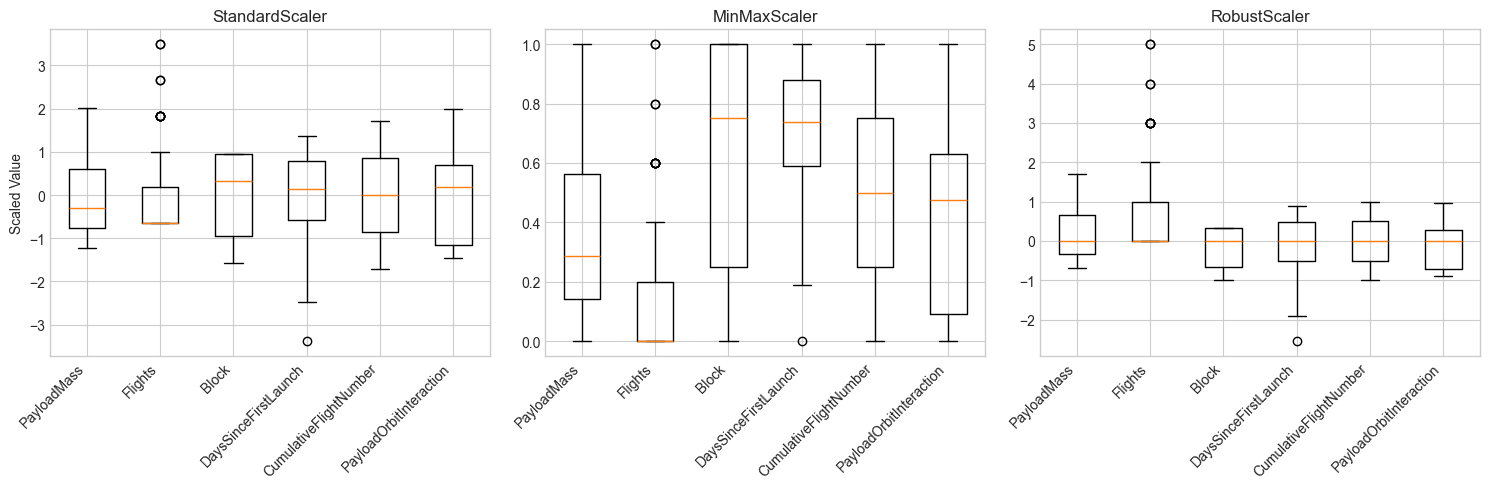


Recommendation: RobustScaler is recommended due to presence of outliers in payload mass.


In [18]:
# Select numeric features for scaling comparison
scale_features = ['PayloadMass', 'Flights', 'Block', 'DaysSinceFirstLaunch', 
                  'CumulativeFlightNumber', 'PayloadOrbitInteraction']

# Create copies for scaling
df_standard = df[scale_features].copy()
df_minmax = df[scale_features].copy()
df_robust = df[scale_features].copy()

# Apply different scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

df_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(df_standard), 
    columns=scale_features
)
df_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(df_minmax), 
    columns=scale_features
)
df_robust_scaled = pd.DataFrame(
    robust_scaler.fit_transform(df_robust), 
    columns=scale_features
)

# Visualize scaling comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot([df_standard_scaled[col] for col in scale_features])
axes[0].set_xticklabels(scale_features, rotation=45, ha='right')
axes[0].set_title('StandardScaler')
axes[0].set_ylabel('Scaled Value')

axes[1].boxplot([df_minmax_scaled[col] for col in scale_features])
axes[1].set_xticklabels(scale_features, rotation=45, ha='right')
axes[1].set_title('MinMaxScaler')

axes[2].boxplot([df_robust_scaled[col] for col in scale_features])
axes[2].set_xticklabels(scale_features, rotation=45, ha='right')
axes[2].set_title('RobustScaler')

plt.tight_layout()
plt.savefig('Datasets/scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRecommendation: RobustScaler is recommended due to presence of outliers in payload mass.")

---

## 12. Final Feature Set Export

Prepare and export the final enhanced feature set for machine learning.

In [19]:
# Define final feature columns (excluding Serial to prevent data leakage)
# Note: Serial numbers can leak information about specific boosters and their history

# Numeric features
numeric_features = [
    'FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount',
    'Year', 'Month', 'Quarter', 'DayOfWeek', 'DaysSinceFirstLaunch',
    'CumulativeFlightNumber', 'DaysSinceBoosterFirstFlight', 'BoosterFlightSequence',
    'BoosterPriorSuccessRate', 'BlockCumulativeFlights',
    'SiteRollingSuccess_5', 'OverallRollingSuccess_5', 'OverallRollingSuccess_10',
    'OrbitRollingSuccess_5', 'SiteCumulativeSuccess', 'OrbitCumulativeSuccess',
    'PayloadCategoryNumeric', 'PayloadMassRelative', 'PayloadMassLog',
    'DistanceToEquator', 'DistanceToCoast', 'AbsoluteLatitude',
    'OrbitDifficulty', 'PayloadOrbitInteraction', 'PayloadPerFlight',
    'ExperienceReuseInteraction', 'LandingHardwareScore', 'BlockReuseInteraction',
    'LandingPadUsed'
]

# Boolean features (will be converted to int)
boolean_features = ['GridFins', 'Reused', 'Legs', 'IsWeekend', 'IsEastCoast']

# Categorical features for one-hot encoding
categorical_features = ['Orbit', 'LaunchSite', 'PayloadCategory']

# Target variable
target = 'Class'

In [20]:
# Prepare final dataset
df_final = df.copy()

# Convert boolean to int
for col in boolean_features:
    df_final[col] = df_final[col].astype(int)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_final[categorical_features], prefix=categorical_features)

# Combine all features
feature_cols = numeric_features + boolean_features
df_features = df_final[feature_cols].copy()
df_features = pd.concat([df_features, df_encoded], axis=1)

# Add target
df_features['Class'] = df_final['Class']

print(f"Final Feature Set Shape: {df_features.shape}")
print(f"Number of features: {df_features.shape[1] - 1}")
print(f"\nFeature Categories:")
print(f"  - Numeric features: {len(numeric_features)}")
print(f"  - Boolean features: {len(boolean_features)}")
print(f"  - One-hot encoded features: {len(df_encoded.columns)}")

Final Feature Set Shape: (90, 58)
Number of features: 57

Feature Categories:
  - Numeric features: 34
  - Boolean features: 5
  - One-hot encoded features: 18


In [21]:
# Display feature correlation with target
correlations = df_features.corr()['Class'].drop('Class').sort_values(ascending=False)

print("Top 20 Features Correlated with Landing Success:")
print("="*50)
for i, (feat, corr) in enumerate(correlations.head(20).items()):
    print(f"{i+1:2}. {feat:40} : {corr:+.4f}")

print("\nBottom 10 Features (Negative Correlation):")
print("="*50)
for i, (feat, corr) in enumerate(correlations.tail(10).items()):
    print(f"{i+1:2}. {feat:40} : {corr:+.4f}")

Top 20 Features Correlated with Landing Success:
 1. LandingHardwareScore                     : +0.6747
 2. Legs                                     : +0.6738
 3. GridFins                                 : +0.6425
 4. LandingPadUsed                           : +0.6414
 5. DaysSinceFirstLaunch                     : +0.4526
 6. ReusedCount                              : +0.4502
 7. Year                                     : +0.4339
 8. Block                                    : +0.4160
 9. FlightNumber                             : +0.4019
10. CumulativeFlightNumber                   : +0.4019
11. OverallRollingSuccess_10                 : +0.3587
12. OverallRollingSuccess_5                  : +0.3383
13. BlockReuseInteraction                    : +0.3235
14. SiteCumulativeSuccess                    : +0.2726
15. OrbitCumulativeSuccess                   : +0.2640
16. SiteRollingSuccess_5                     : +0.2460
17. Quarter                                  : +0.2339
18. PayloadCateg

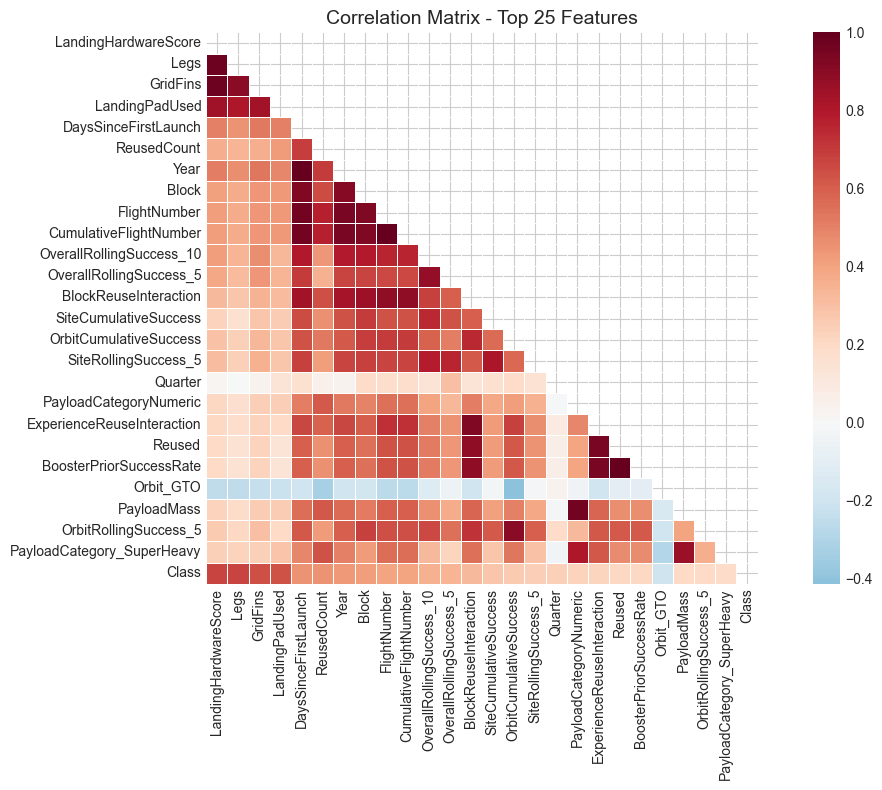

In [22]:
# Visualize feature correlations
plt.figure(figsize=(12, 8))
top_features = correlations.abs().sort_values(ascending=False).head(25).index.tolist()
correlation_subset = df_features[top_features + ['Class']].corr()

mask = np.triu(np.ones_like(correlation_subset, dtype=bool))
sns.heatmap(correlation_subset, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Top 25 Features', fontsize=14)
plt.tight_layout()
plt.savefig('Datasets/feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Export enhanced datasets

# 1. Full enhanced dataset with all features
df_features.to_csv('Datasets/dataset_enhanced_features.csv', index=False)
print("Saved: Datasets/dataset_enhanced_features.csv")

# 2. Export the complete dataframe with all engineered features for reference
df_final.to_csv('Datasets/dataset_complete_engineered.csv', index=False)
print("Saved: Datasets/dataset_complete_engineered.csv")

# 3. Export feature names for later use
feature_names = df_features.drop('Class', axis=1).columns.tolist()
with open('Datasets/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))
print("Saved: Datasets/feature_names.txt")

print(f"\nTotal features exported: {len(feature_names)}")

Saved: Datasets/dataset_enhanced_features.csv
Saved: Datasets/dataset_complete_engineered.csv
Saved: Datasets/feature_names.txt

Total features exported: 57


---

## Summary

### Features Created

| Category | Features | Description |
|----------|----------|-------------|
| Temporal | Year, Month, Quarter, DayOfWeek, DaysSinceFirstLaunch | Time-based patterns |
| Booster Experience | BoosterFlightSequence, DaysSinceBoosterFirstFlight, BoosterPriorSuccessRate | Booster history |
| Rolling Success | SiteRollingSuccess, OrbitRollingSuccess, OverallRollingSuccess | Historical performance |
| Payload | PayloadCategory, PayloadMassLog, PayloadMassRelative | Payload characteristics |
| Geographic | DistanceToEquator, DistanceToCoast, IsEastCoast | Location features |
| Interaction | PayloadOrbitInteraction, LandingHardwareScore, BlockReuseInteraction | Combined effects |

### Key Insights

1. **Temporal patterns**: Success rate improves significantly over time (learning curve)
2. **Booster experience**: More experienced boosters tend to have higher success rates
3. **Payload categories**: Light and medium payloads have higher success rates
4. **Landing hardware**: GridFins and Legs usage strongly correlates with success
5. **Orbit difficulty**: Higher orbit difficulty correlates with lower success rates

### Next Steps

The enhanced feature set is ready for advanced machine learning modeling:
- XGBoost, LightGBM, CatBoost ensemble methods
- SHAP analysis for model interpretability
- Hyperparameter optimization with Optuna

---

## Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)